In [1]:
import pandas as pd


In [2]:
# Load CSV dataset
df = pd.read_csv('employee_data_cleaning.csv')

# Preview first 5 rows
print("Preview first 5 rows:-\n",df.head())

# Get overall info about data types and null values
print("\nGet overall info about data types and null values:-",df.info())

# Summary statistics
print("\nSummary statistics:-\n",df.describe(include='all'))

Preview first 5 rows:-
     Name   Age Department  Salary    Bonus
0   Amit  25.0         HR   40000   5000.0
1   Neha  30.0         IT   60000   7000.0
2    Raj   NaN    Finance   55000   6000.0
3  Priya  28.0         hr   42000      NaN
4  Karan  35.0    IT Dept   80000  12000.0
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        20 non-null     str    
 1   Age         18 non-null     float64
 2   Department  19 non-null     str    
 3   Salary      20 non-null     int64  
 4   Bonus       18 non-null     float64
dtypes: float64(2), int64(1), str(2)
memory usage: 932.0 bytes

Get overall info about data types and null values:- None

Summary statistics:-
         Name        Age Department          Salary         Bonus
count     20  18.000000         19       20.000000     18.000000
unique    19        NaN          6             NaN           NaN
t

Check missing values count:-
 Name          0
Age           2
Department    1
Salary        0
Bonus         2
dtype: int64

Calculate missing value percentage per column:-
 Name           0.0
Age           10.0
Department     5.0
Salary         0.0
Bonus         10.0
dtype: float64


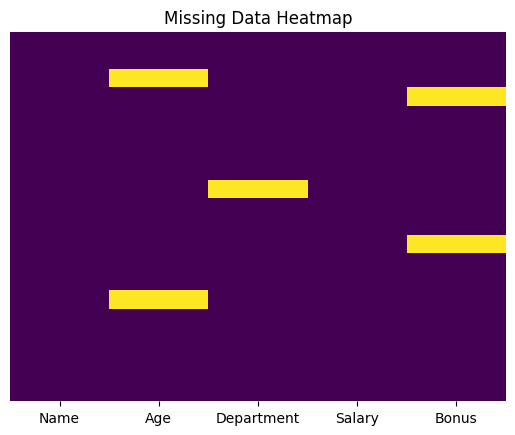

In [3]:
# Check missing values count
print("Check missing values count:-\n",df.isnull().sum())

# Calculate missing value percentage per column
missing_percentage = df.isnull().mean() * 100
print("\nCalculate missing value percentage per column:-\n",missing_percentage)

# Visualize missing values
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

In [4]:
# Drop rows where 'Age' is missing
df = df.dropna(subset=['Age'])

df.fillna({
    'Salary': df['Salary'].mean(),
    'Bonus': df['Bonus'].median(),
    'Department': df['Department'].mode()[0]
}, inplace=True)


,Name,Age,Department,Salary,Bonus
0,Amit,25.0,HR,40000,5000.0
1,Neha,30.0,IT,60000,7000.0
3,Priya,28.0,hr,42000,6900.0
4,Karan,35.0,IT Dept,80000,12000.0
5,Simran,27.0,Finance,52000,6500.0
6,Amit,25.0,HR,40000,5000.0
7,Rohit,45.0,Management,150000,20000.0
8,Sneha,29.0,Finance,48000,5500.0
9,Vikas,31.0,IT,62000,7200.0
10,Anjali,26.0,HR,41000,5000.0


In [5]:
# IQR Method
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

df_cleaned = df[~((df['Salary'] < (Q1 - 1.5 * IQR)) | 
                  (df['Salary'] > (Q3 + 1.5 * IQR)))]

print("After IQR:")
print(df_cleaned)


# Z-score Method
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df['Salary']))
df_no_outliers = df[(z_scores < 3)]

print("\nAfter Z-score:")
print(df_no_outliers)

After IQR:
      Name   Age Department  Salary    Bonus
0     Amit  25.0         HR   40000   5000.0
1     Neha  30.0         IT   60000   7000.0
3    Priya  28.0         hr   42000   6900.0
4    Karan  35.0    IT Dept   80000  12000.0
5   Simran  27.0    Finance   52000   6500.0
6     Amit  25.0         HR   40000   5000.0
8    Sneha  29.0    Finance   48000   5500.0
9    Vikas  31.0         IT   62000   7200.0
10  Anjali  26.0         HR   41000   5000.0
11  Deepak  33.0    Finance   58000   6900.0
12   Pooja  29.0    IT Dept   61000   7100.0
15  Suresh  38.0    Finance   57000   6800.0
16  Kavita  27.0         hr   43000   5200.0
18    Rina  28.0    Finance   53000   6000.0
19    Alok  32.0    IT Dept   61000   7100.0

After Z-score:
      Name   Age  Department  Salary    Bonus
0     Amit  25.0          HR   40000   5000.0
1     Neha  30.0          IT   60000   7000.0
3    Priya  28.0          hr   42000   6900.0
4    Karan  35.0     IT Dept   80000  12000.0
5   Simran  27.0     Fi

In [6]:
# Count duplicate rows
print(df.duplicated().sum())
# Drop duplicates
df = df.drop_duplicates()

1


In [7]:
# Standardize text
df['Department'] = df['Department'].str.lower().str.strip()

# Replace values (NO inplace)
df['Department'] = df['Department'].replace({
    'hr': 'human resources',
    'it dept': 'it'
})

# SHOW OUTPUT
print(df['Department'])

0     human resources
1                  it
3     human resources
4                  it
5             finance
7          management
8             finance
9                  it
10    human resources
11            finance
12                 it
13         management
15            finance
16    human resources
17                 it
18            finance
19                 it
Name: Department, dtype: str
